In [44]:
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import random
from networkx.algorithms.community import louvain_communities
import os
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [24]:
# negative sampling parameters
MIN_MODULE_SIZE = 5
NEGATIVE_RATIO = 1
DEGREE_TOLERANCE = 2

## Load Data

In [25]:
# disease-level ppi
with open("../data/ppi.pkl", "rb") as f:
    ppi = pickle.load(f)

# species full biogrid ppi
with open("../data/biogrid.pkl", "rb") as f:
    biogrid = pickle.load(f)

# human to other organism mapping
mapping = pd.read_csv("../data/homolog_mapping.csv")

# networks
with open("../data/networks.pkl", "rb") as f:
    networks = pickle.load(f)

# hubs
with open("../data/hubs.pkl", "rb") as f:
    hubs = pickle.load(f)

## Negative Samples for Disease Prediction

In [26]:
# biogrid full human network
human_df = biogrid.get('Homo_sapiens', list(biogrid.values())[0])
full_human_G = nx.from_pandas_edgelist(
    human_df, 
    source='Official Symbol Interactor A', 
    target='Official Symbol Interactor B'
)
full_human_nodes = set(full_human_G.nodes())

In [27]:
# find modules in graph
def find_modules(G, min_size=MIN_MODULE_SIZE, seed=RANDOM_SEED):
    communities = louvain_communities(G, seed=seed)
    return [set(c) for c in communities if len(c) >= min_size]

def build_degree_index(genes, graph):
    degree_index = {}
    for g in genes:
        deg = graph.degree(g)
        degree_index.setdefault(deg, []).append(g)
    return degree_index

def sample_degree_matched_negatives(
    positive_genes, degree_index, graph, ratio=NEGATIVE_RATIO, tolerance=DEGREE_TOLERANCE
 ):
    sampled = []
    used = set()
    available_degrees = sorted(degree_index.keys())

    for pos_gene in positive_genes:
        target_deg = graph.degree(pos_gene)

        for _ in range(ratio):
            candidates = []
            for d in range(target_deg - tolerance, target_deg + tolerance + 1):
                for gene in degree_index.get(d, []):
                    if gene not in used:
                        candidates.append(gene)

            # fallback: nearest degree bucket if strict tolerance has no candidates
            if not candidates and available_degrees:
                nearest_deg = min(available_degrees, key=lambda d: abs(d - target_deg))
                candidates = [g for g in degree_index[nearest_deg] if g not in used]

            if not candidates:
                continue

            chosen = random.choice(candidates)
            sampled.append(chosen)
            used.add(chosen)

    return sampled

# negative sampling to train model
diseases = list(networks.keys())
negative_features = []
all_negative_genes = set()

for d in diseases:
    print(f"Processing {d}")
    G_h = networks[d]["human"]
    positive_genes = set(G_h.nodes())

    # define negative pool as everything in biogrid not associated with this disease
    negative_pool = list(full_human_nodes - positive_genes)
    degree_index = build_degree_index(negative_pool, full_human_G)

    # sample negatives with degree matching against positive genes
    sampled_negatives = sample_degree_matched_negatives(
        sorted(positive_genes),
        degree_index,
        full_human_G,
        ratio=NEGATIVE_RATIO,
        tolerance=DEGREE_TOLERANCE,
    )
    all_negative_genes.update(sampled_negatives)

    # recalculate disease modules to get module-relative features
    modules = find_modules(G_h)

    for gene in sampled_negatives:
        global_degree = full_human_G.degree(gene)

        for module_id, module in enumerate(modules):
            module_size = len(module)

            module_degree = sum(1 for mod_node in module if full_human_G.has_edge(gene, mod_node))
            mod_deg_norm = module_degree / module_size if module_size > 0 else 0

            negative_features.append({
                "gene": gene,
                "disease": d,
                "module_id": module_id,
                "module_degree": module_degree,
                "global_degree": global_degree,
                "module_size": module_size,
                "mod_deg_norm": mod_deg_norm,
                "label": 0
            })

Processing AD
Processing PD
Processing COVID
Processing BC


In [28]:
# save negative features to csv
neg_df = pd.DataFrame(negative_features)
neg_df.to_csv("../data/negative_features_partial.csv", index=False)

In [29]:
# save gene list for blast
with open("../data/negative_genes_to_blast.txt", "w") as f:
    for gene in all_negative_genes:
        f.write(f"{gene}\n")

print(f"{len(all_negative_genes)} unique negative genes")

7000 unique negative genes


In [ ]:
# fetch FASTA sequences for negative genes from UniProt
input_file = "../data/negative_genes_to_blast.txt"
output_file = "../data/negative_genes.fasta"

with open(input_file, "r") as f:
    genes = [line.strip() for line in f if line.strip()]

# submit batch request for ID mapping
def submit_id_mapping(ids):
    return requests.post(
        "https://rest.uniprot.org/idmapping/run",
        data={
            "from": "Gene_Name",
            "to": "UniProtKB",
            "ids": ",".join(ids),
            "taxId": "9606"
        },
    ).json()

# check job status and wait until finished
def get_id_mapping_results(job_id):
    while True:
        r = requests.get(f"https://rest.uniprot.org/idmapping/status/{job_id}")
        job = r.json()
        if "jobStatus" in job:
            if job["jobStatus"] == "RUNNING":
                print("Job still running... waiting 10s")
                time.sleep(10)
            elif job["jobStatus"] == "FINISHED":
                return True
            else:
                print(f"Job failed: {job['jobStatus']}")
                return False
        else:
            return True

job_info = submit_id_mapping(genes)
job_id = job_info["jobId"]
print(f"Job ID: {job_id}")

if get_id_mapping_results(job_id):
    print("Job finished.")
    stream_url = f"https://rest.uniprot.org/idmapping/uniprotkb/results/stream/{job_id}"
    params = {"format": "fasta"}
    
    with requests.get(stream_url, params=params, stream=True) as r:
        r.raise_for_status()
        with open(output_file, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

Job ID: cCGdghdqq1
Job still running... waiting 10s
Job still running... waiting 10s
Job still running... waiting 10s
Job still running... waiting 10s
Job still running... waiting 10s
Job still running... waiting 10s
Job finished. Downloading FASTA data...


### Run BLAST

```bash
blastp -query ../data/negative_genes.fasta \
       -db ../data/proteomes/blast_db/human/human \
       -num_threads 10 \
       -max_target_seqs 1 \
       -out ../data/proteomes/blast_results/negative_vs_human.tsv \
       -outfmt "6 qseqid sseqid bitscore evalue"

blastp -query ../data/negative_genes.fasta \
       -db ../data/proteomes/blast_db/mouse/mouse \
       -num_threads 10 \
       -max_target_seqs 1 \
       -out ../data/proteomes/blast_results/negative_vs_mouse.tsv \
       -outfmt "6 qseqid sseqid bitscore evalue"

blastp -query ../data/negative_genes.fasta \
       -db ../data/proteomes/blast_db/yeast/yeast \
       -num_threads 10 \
       -max_target_seqs 1 \
       -out ../data/proteomes/blast_results/negative_vs_yeast.tsv \
       -outfmt "6 qseqid sseqid bitscore evalue"

blastp -query ../data/negative_genes.fasta \
       -db ../data/proteomes/blast_db/fly/fly \
       -num_threads 10 \
       -max_target_seqs 1 \
       -out ../data/proteomes/blast_results/negative_vs_fly.tsv \
       -outfmt "6 qseqid sseqid bitscore evalue"
```

### Bitscore Ratio Calculation

In [31]:
# parse FASTA headers to map back to gene symbols
qseqid_to_gene = {}
with open("../data/negative_genes.fasta", "r") as f:
    for line in f:
        if line.startswith(">"):
            header = line.strip()
            qseqid = header.split(" ")[0][1:]
            if "GN=" in header:
                gene = header.split("GN=")[1].split(" ")[0]
                qseqid_to_gene[qseqid] = gene

# load blast output
cols = ["qseqid", "sseqid", "bitscore", "evalue"]
blast_h = pd.read_csv("../data/proteomes/blast_results/negative_vs_human.tsv", sep="\t", names=cols)
blast_m = pd.read_csv("../data/proteomes/blast_results/negative_vs_mouse.tsv", sep="\t", names=cols)
blast_y = pd.read_csv("../data/proteomes/blast_results/negative_vs_yeast.tsv", sep="\t", names=cols)
blast_f = pd.read_csv("../data/proteomes/blast_results/negative_vs_fly.tsv", sep="\t", names=cols)

In [32]:
def get_max_bitscore(blast_df, col_name):
    blast_df["gene"] = blast_df["qseqid"].map(qseqid_to_gene)
    blast_df = blast_df.dropna(subset=["gene"])
    return blast_df.groupby("gene")["bitscore"].max().reset_index().rename(columns={"bitscore": col_name})

h_max = get_max_bitscore(blast_h, "h_bitscore")
m_max = get_max_bitscore(blast_m, "mouse_bitscore")
y_max = get_max_bitscore(blast_y, "yeast_bitscore")
f_max = get_max_bitscore(blast_f, "fly_bitscore")

# merge all bitscores into one dataframe
bsr_df = h_max.merge(m_max, on="gene", how="left")\
              .merge(y_max, on="gene", how="left")\
              .merge(f_max, on="gene", how="left")
bsr_df = bsr_df.fillna(0) # 0 bitscore if no ortholog hit
bsr_df = bsr_df[bsr_df["h_bitscore"] > 0]

bsr_df["mouse"] = bsr_df["mouse_bitscore"] / bsr_df["h_bitscore"]
bsr_df["yeast"] = bsr_df["yeast_bitscore"] / bsr_df["h_bitscore"]
bsr_df["fly"] = bsr_df["fly_bitscore"] / bsr_df["h_bitscore"]

# long format to match postive features
bsr_long = pd.melt(
    bsr_df,
    id_vars=["gene"],
    value_vars=["mouse", "yeast", "fly"],
    var_name="species",
    value_name="BSR"
)

In [33]:
neg_features = pd.read_csv("../data/negative_features_partial.csv")
neg_merged = pd.merge(neg_features, bsr_long, on="gene", how="inner")

# node conservation scores
cons_scores = pd.read_csv("../data/conservation_scores.csv")
module_cons = cons_scores[["disease", "species", "module_id", "node_conservation"]].drop_duplicates()

# left join to assign the target disease module's conservation score to the negative gene's feature vector
final_negatives = pd.merge(neg_merged, module_cons, on=["disease", "species", "module_id"], how="left")
final_negatives

,gene,disease,module_id,module_degree,global_degree,module_size,mod_deg_norm,label,species,BSR,node_conservation
0,FOXL1,AD,0,6,194,194,0.030928,0,mouse,2.260355,0.887681
1,FOXL1,AD,0,6,194,194,0.030928,0,yeast,0.544379,0.206522
2,FOXL1,AD,0,6,194,194,0.030928,0,fly,0.976331,0.485507
3,FOXL1,AD,1,3,194,216,0.013889,0,mouse,2.260355,0.906667
4,FOXL1,AD,1,3,194,216,0.013889,0,yeast,0.544379,0.373333
...,...,...,...,...,...,...,...,...,...,...,...
593764,SCMH1,BC,19,0,56,83,0.000000,0,yeast,0.119084,0.000000
593765,SCMH1,BC,19,0,56,83,0.000000,0,fly,1.156489,0.000000
593766,SCMH1,BC,20,1,56,16,0.062500,0,mouse,4.736641,0.843373
593767,SCMH1,BC,20,1,56,16,0.062500,0,yeast,0.119084,0.060241


In [34]:
# combine positives and negatives
positives = pd.read_csv("../data/bitscores.csv")
positives["label"] = 1

# keep leakage-resistant columns for model training
common_cols = [
    "gene", "disease", "module_size", "species",
    "node_conservation", "BSR", "label"
]

# final dataset for model training
final_dataset = pd.concat([
    positives[common_cols],
    final_negatives[common_cols]
], ignore_index=True)

# one hot encode species
final_dataset = pd.get_dummies(final_dataset, columns=["species"])

# drop any rows with missing values (e.g. missing conservation scores)
final_dataset = final_dataset.dropna()
final_dataset.to_csv("../data/final_disease_prediction_features.csv", index=False)

## Logistic Regression Model

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

In [47]:
# load the data
df = pd.read_csv("../data/final_disease_prediction_features.csv")

# conservation-focused feature set
features = [
    "node_conservation", "BSR", "module_size"
]

# species columns
species_cols = {
    "Mouse": "species_mouse",
    "Yeast": "species_yeast",
    "Fly": "species_fly"
}

In [39]:
# store results for each species
results = {}

# train separate model for each species to compare conservation-driven signal across organisms
for species_name, col_name in species_cols.items():
    print(f"\nTraining Model for {species_name}\n{'-'*40}")

    # filter dataset for current species
    species_df = df[df[col_name] == True].copy()

    # skip species with insufficient class diversity
    if species_df["label"].nunique() < 2:
        print("Skipping: only one class present after filtering.")
        continue

    X = species_df[features]
    y = species_df["label"]

    # stratified split to maintain class balance in train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # standardize features to make coefficients comparable and help model convergence
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # initialize model with class balancing
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)

    # predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # which covariates are the most informative
    coefs = pd.DataFrame({
        'Feature': features,
        'Coefficient': model.coef_[0],
        'Abs_Coefficient': np.abs(model.coef_[0])
    }).sort_values(by='Abs_Coefficient', ascending=False)

    print("Feature Importance (Standardized Coefficients):")
    print(coefs[['Feature', 'Coefficient']].to_string(index=False))

    results[species_name] = {
        "model": model,
        "scaler": scaler,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "coefs": coefs
    }


Training Model for Mouse
----------------------------------------
ROC-AUC: 0.8748
PR-AUC:  0.2771

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82     38952
           1       0.15      0.91      0.26      2257

    accuracy                           0.71     41209
   macro avg       0.57      0.80      0.54     41209
weighted avg       0.95      0.71      0.79     41209

Feature Importance (Standardized Coefficients):
          Feature  Coefficient
              BSR   -35.430203
      module_size     0.700981
node_conservation     0.015772

Training Model for Yeast
----------------------------------------
ROC-AUC: 0.8088
PR-AUC:  0.1850

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79     38952
           1       0.12      0.81      0.21      2257

    accuracy                           0.67     41209
   macro avg       0.55      0.74    

## XGBoost Model for Nonlinear Signal

In [41]:
from xgboost import XGBClassifier

results = {}

for species_name, col_name in species_cols.items():
    print(f"\nTraining XGBoost Model for {species_name}\n{'-'*40}")
    
    species_df = df[df[col_name] == True].copy() 
    
    if species_df.empty:
        print(f"No data found for {species_name}.")
        continue

    X = species_df[features]
    y = species_df["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # class balancing
    neg_count = len(y_train[y_train == 0])
    pos_count = len(y_train[y_train == 1])
    scale_weight = neg_count / pos_count if pos_count > 0 else 1
    
    # low depth to avoid overfitting
    model = XGBClassifier(
        scale_pos_weight=scale_weight,
        max_depth=4,
        learning_rate=0.1,
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    # train the model
    model.fit(X_train, y_train)
    
    # predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob) 
    
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # feature importance based on relative information gain
    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    print("Feature Importance (Relative Information Gain):")
    print(importances.to_string(index=False))
    
    results[species_name] = {
        "model": model,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "importances": importances
    }


Training XGBoost Model for Mouse
----------------------------------------


/Users/sree/miniforge3/envs/bst281final/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:30:29] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.8904
PR-AUC:  0.3071

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83     38952
           1       0.16      0.93      0.27      2257

    accuracy                           0.72     41209
   macro avg       0.58      0.82      0.55     41209
weighted avg       0.95      0.72      0.80     41209

Feature Importance (Relative Information Gain):
          Feature  Importance
              BSR    0.758325
      module_size    0.221621
node_conservation    0.020054

Training XGBoost Model for Yeast
----------------------------------------


/Users/sree/miniforge3/envs/bst281final/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:30:30] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.8339
PR-AUC:  0.2432

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80     38952
           1       0.13      0.83      0.22      2257

    accuracy                           0.68     41209
   macro avg       0.56      0.75      0.51     41209
weighted avg       0.94      0.68      0.76     41209

Feature Importance (Relative Information Gain):
          Feature  Importance
              BSR    0.583508
      module_size    0.363109
node_conservation    0.053383

Training XGBoost Model for Fly
----------------------------------------


/Users/sree/miniforge3/envs/bst281final/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:30:30] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.8480
PR-AUC:  0.2575

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     38952
           1       0.13      0.88      0.23      2257

    accuracy                           0.67     41209
   macro avg       0.56      0.77      0.51     41209
weighted avg       0.94      0.67      0.76     41209

Feature Importance (Relative Information Gain):
          Feature  Importance
              BSR    0.637879
      module_size    0.323377
node_conservation    0.038744


## Plotting

/var/folders/_2/8p_kmtx12_l4hhv4d81frcf80000gn/T/ipykernel_31519/26261120.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_list, y=pr_aucs, ax=axes[0], palette="viridis")
/var/folders/_2/8p_kmtx12_l4hhv4d81frcf80000gn/T/ipykernel_31519/26261120.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


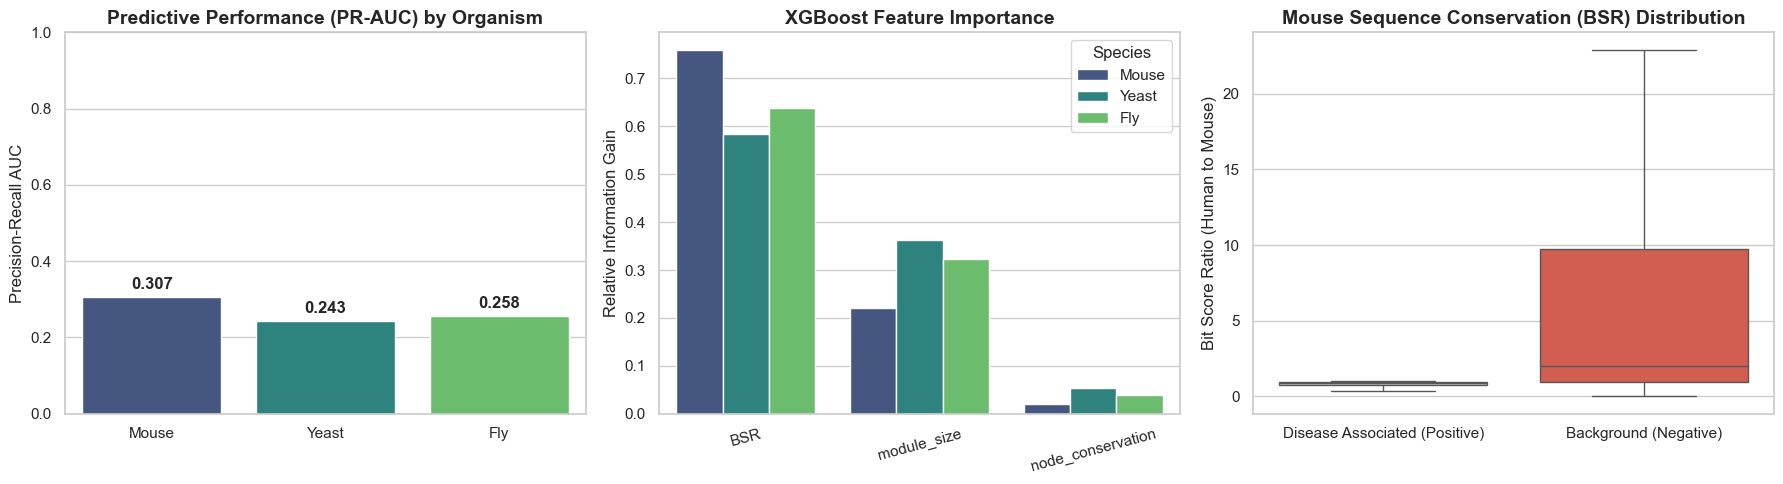

In [ ]:
# visualization of results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# predictive performance comparison
species_list = list(results.keys())
pr_aucs = [results[s]["pr_auc"] for s in species_list]

sns.barplot(x=species_list, y=pr_aucs, ax=axes[0], palette="viridis")
axes[0].set_title("Predictive Performance (PR-AUC) by Organism", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Precision-Recall AUC")
axes[0].set_ylim(0, 1.0) # Set to 1.0 to visually emphasize how low the ceiling is

# Add text labels on bars
for i, v in enumerate(pr_aucs):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# feature importance comparison
imp_data = []
for species in species_list:
    df_imp = results[species]["importances"].copy()
    df_imp["Species"] = species
    imp_data.append(df_imp)

imp_df_all = pd.concat(imp_data, ignore_index=True)

sns.barplot(
    data=imp_df_all, 
    x="Feature", 
    y="Importance", 
    hue="Species", 
    ax=axes[1], 
    palette="viridis"
)
axes[1].set_title("XGBoost Feature Importance", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Relative Information Gain")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=15)

# disease background vs disease associated conservation scores
mouse_df = df[df["species_mouse"] == True].copy()
mouse_df["Class"] = mouse_df["label"].map({0: "Background (Negative)", 1: "Disease Associated (Positive)"})

sns.boxplot(
    data=mouse_df, 
    x="Class", 
    y="BSR", 
    ax=axes[2], 
    palette=["#bdc3c7", "#e74c3c"],
    showfliers=False
)
axes[2].set_title("Mouse Sequence Conservation (BSR) Distribution", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Bit Score Ratio (Human to Mouse)")
axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig("../figures/module4_prediction_summary.png", dpi=300, bbox_inches="tight")
plt.show()

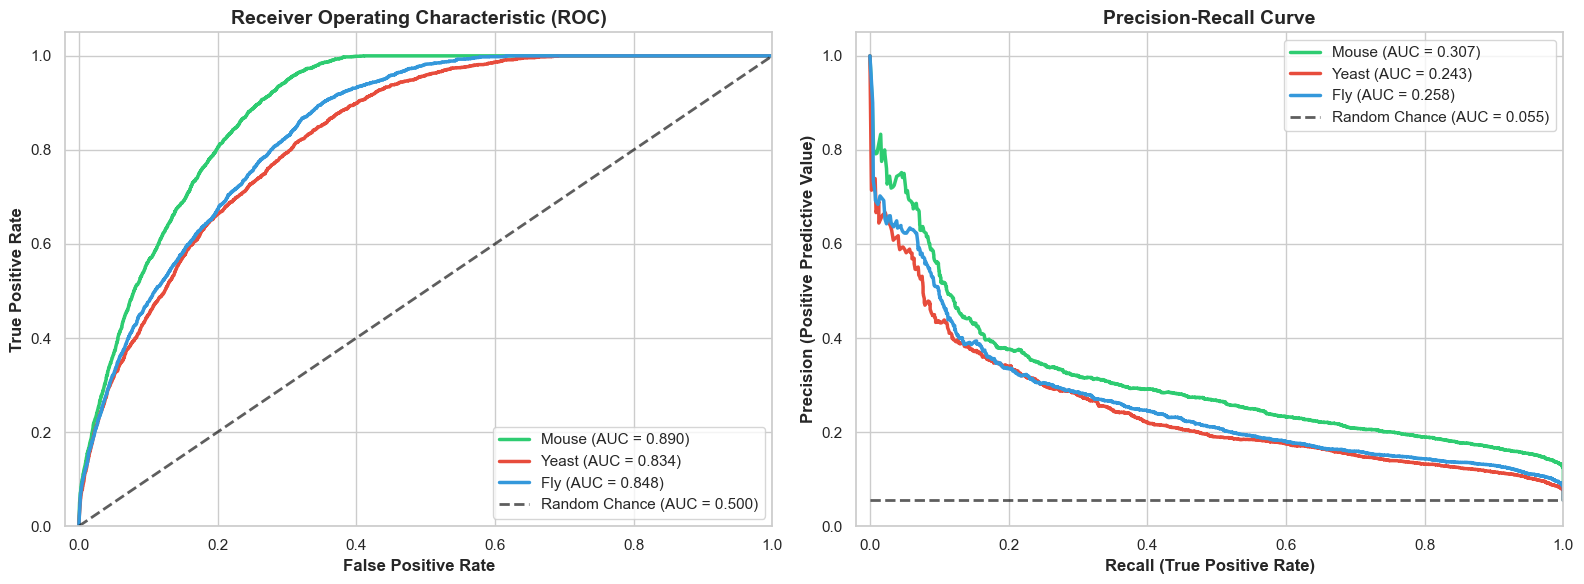

In [50]:
from sklearn.metrics import roc_curve, precision_recall_curve

# colors for consistent plotting
colors = {"Mouse": "#2ecc71", "Yeast": "#e74c3c", "Fly": "#3498db"}

# initialize subplots for ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

for species_name, col_name in species_cols.items():
    if species_name not in results:
        continue
        
    species_df = df[df[col_name] == True]
    X = species_df[features]
    y = species_df["label"]
    
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model = results[species_name]["model"]
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # roc curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = results[species_name]["roc_auc"]
    
    axes[0].plot(
        fpr, tpr, 
        label=f"{species_name} (AUC = {roc_auc:.3f})", 
        color=colors[species_name], 
        lw=2.5
    )
    
    # precision-recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = results[species_name]["pr_auc"]
    
    axes[1].plot(
        recall, precision, 
        label=f"{species_name} (AUC = {pr_auc:.3f})", 
        color=colors[species_name], 
        lw=2.5
    )

# format left panel roc curve
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.7, label="Random Chance (AUC = 0.500)")
axes[0].set_xlim([-0.02, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=11, frameon=True)

# format right panel precision-recall curve
baseline = y_test.mean()
axes[1].plot([0, 1], [baseline, baseline], 'k--', lw=2, alpha=0.7, label=f"Random Chance (AUC = {baseline:.3f})")
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig("../figures/module4_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()